In [1]:
from pathlib import Path
import sys
import random
import copy
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

PROJECT_DIR = Path.cwd()
MODULE_DIR_CANDIDATES = [
    PROJECT_DIR,
    PROJECT_DIR / "TACC",
    PROJECT_DIR.parent / "TACC",
]
for module_dir in MODULE_DIR_CANDIDATES:
    if (module_dir / "DataProcessing.py").exists():
        if str(module_dir) not in sys.path:
            sys.path.insert(0, str(module_dir))
        break
else:
    raise FileNotFoundError("Could not locate DataProcessing.py from the current notebook working directory.")

from DataProcessing import time_gaps, SENSOR_COLS, ACTUATOR_COLS


In [2]:
SEQ_LEN = 100
STRIDE = 1
INPUT_DIM = 51

BATCH_SIZE = 512
EPOCHS = 100
PATIENCE = 8
ATTACK_CONTEXT_PAD_SECONDS = 15 * 60
CV_FOLDS = 6
RANDOM_SEED = 42

BEST_PARAMS = {
    "score_mode": "topk",
    "conv_channels": 32,
    "kernel_size": 3,
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.052372315664381865,
    "bidirectional": True,
    "learning_rate": 6.576610812351347e-05,
    "weight_decay": 1.096217979111254e-06,
    "threshold_percentile": 90.11039913546175,
    "top_k": 7,
}


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def resolve_dataset_dir() -> Path:
    candidates = [
        PROJECT_DIR / "Dataset",
        PROJECT_DIR.parent / "Dataset",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate the Dataset directory from the current notebook working directory.")


DATASET_DIR = resolve_dataset_dir()
set_global_seed(RANDOM_SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", device)
print("DATASET_DIR:", DATASET_DIR)


device: mps
DATASET_DIR: /Users/cacslab/Desktop/TACC/Code/Dataset


#### Data processing

In [3]:
def build_attack_segments(df_attack: pd.DataFrame, context_pad_seconds: int):
    attack_only = df_attack.loc[df_attack["Label"] == 1, ["Timestamp", "Detailed_Label"]].copy()
    attack_only = attack_only.sort_values("Timestamp").reset_index(drop=True)

    is_new_segment = (
        (attack_only["Detailed_Label"] != attack_only["Detailed_Label"].shift(1))
        | (attack_only["Timestamp"].diff().dt.total_seconds().fillna(1) != 1)
    )
    attack_only["attack_segment_id"] = is_new_segment.cumsum().astype(int)

    segment_table = (
        attack_only.groupby(["attack_segment_id", "Detailed_Label"])
        .agg(
            start=("Timestamp", "min"),
            end=("Timestamp", "max"),
            rows=("Timestamp", "size"),
        )
        .reset_index()
        .sort_values("attack_segment_id")
        .reset_index(drop=True)
    )

    pad = pd.Timedelta(seconds=context_pad_seconds)
    global_start = df_attack["Timestamp"].min()
    global_end = df_attack["Timestamp"].max()
    context_starts = []
    context_ends = []

    for i in range(len(segment_table)):
        segment_start = segment_table.loc[i, "start"]
        segment_end = segment_table.loc[i, "end"]

        if i == 0:
            prev_midpoint = global_start
        else:
            prev_end = segment_table.loc[i - 1, "end"]
            prev_midpoint = prev_end + (segment_start - prev_end) / 2

        if i == len(segment_table) - 1:
            next_midpoint = global_end
        else:
            next_start = segment_table.loc[i + 1, "start"]
            next_midpoint = segment_end + (next_start - segment_end) / 2

        context_starts.append(max(segment_start - pad, prev_midpoint))
        context_ends.append(min(segment_end + pad, next_midpoint))

    segment_table["context_start"] = context_starts
    segment_table["context_end"] = context_ends
    return attack_only[["Timestamp", "attack_segment_id"]], segment_table


def assign_context_groups(df_attack: pd.DataFrame, segment_table: pd.DataFrame):
    df = df_attack.copy()
    df["context_group"] = 0

    for row in segment_table.itertuples(index=False):
        mask = (df["Timestamp"] >= row.context_start) & (df["Timestamp"] <= row.context_end)
        df.loc[mask, "context_group"] = int(row.attack_segment_id)

    attack_mask = df["Label"] == 1
    df.loc[attack_mask, "context_group"] = df.loc[attack_mask, "attack_segment_id"]
    return df


def fit_mixed_scaler(train_df: pd.DataFrame, feature_cols):
    sensor_cols = [col for col in feature_cols if col in SENSOR_COLS]
    actuator_cols = [col for col in feature_cols if col in ACTUATOR_COLS]
    unknown_cols = [col for col in feature_cols if col not in SENSOR_COLS and col not in ACTUATOR_COLS]

    if unknown_cols:
        raise ValueError(f"Unknown feature columns without scaling rule: {unknown_cols}")

    scaler_bundle = {
        "sensor_cols": sensor_cols,
        "actuator_cols": actuator_cols,
    }

    if sensor_cols:
        sensor_scaler = StandardScaler()
        sensor_scaler.fit(train_df[sensor_cols])
        scaler_bundle["sensor_scaler"] = sensor_scaler

    if actuator_cols:
        actuator_max = train_df[actuator_cols].max(axis=0).replace(0, 1.0).astype(np.float32)
        scaler_bundle["actuator_max"] = actuator_max

    return scaler_bundle


def transform_with_mixed_scaler(df: pd.DataFrame, feature_cols, scaler_bundle):
    transformed = pd.DataFrame(index=df.index, columns=feature_cols, dtype=np.float32)

    sensor_cols = scaler_bundle["sensor_cols"]
    actuator_cols = scaler_bundle["actuator_cols"]

    if sensor_cols:
        transformed.loc[:, sensor_cols] = scaler_bundle["sensor_scaler"].transform(df[sensor_cols]).astype(np.float32)

    if actuator_cols:
        transformed.loc[:, actuator_cols] = df[actuator_cols].div(scaler_bundle["actuator_max"], axis=1).astype(np.float32)

    return transformed.to_numpy(dtype=np.float32)


def make_window_arrays(
    df: pd.DataFrame,
    feature_cols,
    scaler_bundle,
    seq_len: int,
    stride: int,
    drop_outside_context: bool = False,
):
    X = transform_with_mixed_scaler(df, feature_cols, scaler_bundle)
    y = df["Label"].to_numpy(dtype=np.int64)
    timestamps = pd.to_datetime(df["Timestamp"]).to_numpy()
    ts_seconds = pd.to_datetime(pd.Series(timestamps)).astype("int64") // 10**9
    ts_seconds = ts_seconds.to_numpy()

    attack_segment_ids = df["attack_segment_id"].to_numpy(dtype=np.int64)
    context_groups = df["context_group"].to_numpy(dtype=np.int64)

    X_seq = []
    y_seq = []
    records = []
    skipped_windows = 0
    mixed_attack_windows = 0
    outside_context_windows = 0

    for start in range(0, len(X) - seq_len + 1, stride):
        end = start + seq_len
        if not np.all(np.diff(ts_seconds[start:end]) == 1):
            skipped_windows += 1
            continue

        attack_ids = np.unique(attack_segment_ids[start:end][attack_segment_ids[start:end] > 0])
        if len(attack_ids) > 1:
            mixed_attack_windows += 1
            continue

        label = int(y[start:end].max())
        center_idx = start + seq_len // 2

        if label == 1:
            attack_segment_id = int(attack_ids[0])
            context_group = attack_segment_id
        else:
            attack_segment_id = 0
            context_group = int(context_groups[center_idx])
            if drop_outside_context and context_group == 0:
                outside_context_windows += 1
                continue

        X_seq.append(X[start:end])
        y_seq.append(label)
        records.append({
            "window_start": timestamps[start],
            "window_end": timestamps[end - 1],
            "window_center": timestamps[center_idx],
            "label": label,
            "context_group": context_group,
            "attack_segment_id": attack_segment_id,
        })

    X_seq = np.asarray(X_seq, dtype=np.float32)
    y_seq = np.asarray(y_seq, dtype=np.int64)
    meta_df = pd.DataFrame(records)
    return X_seq, y_seq, meta_df, skipped_windows, mixed_attack_windows, outside_context_windows


def load_group_cv_data(start_time, drop_columns, context_pad_seconds):
    df_normal = pd.read_parquet(DATASET_DIR / "SWaT_Dataset_Normal_v1.parquet")
    df_attack = pd.read_parquet(DATASET_DIR / "SWaT_Dataset_Attack_v1.parquet")

    df_normal["Timestamp"] = pd.to_datetime(df_normal["Timestamp"])
    df_attack["Timestamp"] = pd.to_datetime(df_attack["Timestamp"])

    print("\n------------------------- Original Data -------------------------")
    print(f"Normal Data = {df_normal.shape}")
    print(f"Attack Data = {df_attack.shape}")
    print("\n------------------------- Processing ... -------------------------")

    keep_mask = df_normal["Timestamp"] >= start_time
    df_normal = df_normal.loc[keep_mask].reset_index(drop=True)
    skipped_rows = int((~keep_mask).sum())
    print(f"Normal data = {df_normal.shape}")
    print(f"Skip data = {skipped_rows}")

    segment_lookup, segment_table = build_attack_segments(df_attack, context_pad_seconds)
    df_attack = df_attack.merge(segment_lookup, on="Timestamp", how="left")
    df_attack["attack_segment_id"] = df_attack["attack_segment_id"].fillna(0).astype(int)
    df_attack = assign_context_groups(df_attack, segment_table)

    train_normal_df, tmp_normal_df = train_test_split(df_normal, train_size=0.8, shuffle=False)
    earlystop_normal_df, threshold_normal_df = train_test_split(tmp_normal_df, train_size=0.5, shuffle=False)

    train_gaps = time_gaps(train_normal_df)
    earlystop_gaps = time_gaps(earlystop_normal_df)
    threshold_gaps = time_gaps(threshold_normal_df)
    attack_gaps = time_gaps(df_attack)

    feature_cols = [
        col for col in df_attack.columns
        if col not in {"Timestamp", "Label", "Detailed_Label", "attack_segment_id", "context_group"}
    ]

    print(f"train_normal_df = {train_normal_df.shape}")
    print(f"earlystop_normal_df = {earlystop_normal_df.shape}")
    print(f"threshold_normal_df = {threshold_normal_df.shape}")
    print(f"attack_eval_df = {df_attack.shape}")
    print(f"attack segments = {len(segment_table)}")
    print(f"train gaps: {len(train_gaps)}")
    print(f"earlystop gaps: {len(earlystop_gaps)}")
    print(f"threshold gaps: {len(threshold_gaps)}")
    print(f"attack gaps: {len(attack_gaps)}")
    print("\nAttack Segment Summary")
    print(segment_table[["attack_segment_id", "Detailed_Label", "rows", "context_start", "context_end"]].to_string(index=False))

    return train_normal_df, earlystop_normal_df, threshold_normal_df, df_attack, segment_table, feature_cols


start_time = pd.to_datetime("2015-12-23 12:00:00")
drop_columns = ["Detailed_Label"]

train_normal_df, earlystop_normal_df, threshold_normal_df, attack_eval_df, segment_table, feature_cols = load_group_cv_data(
    start_time=start_time,
    drop_columns=drop_columns,
    context_pad_seconds=ATTACK_CONTEXT_PAD_SECONDS,
)

INPUT_DIM = len(feature_cols)
print("INPUT_DIM:", INPUT_DIM)



------------------------- Original Data -------------------------
Normal Data = (495000, 54)
Attack Data = (449919, 54)

------------------------- Processing ... -------------------------
Normal data = (424800, 54)
Skip data = 70200
train_normal_df = (339840, 54)
earlystop_normal_df = (42480, 54)
threshold_normal_df = (42480, 54)
attack_eval_df = (449919, 56)
attack segments = 36
train gaps: 0
earlystop gaps: 0
threshold gaps: 0
attack gaps: 1

Attack Segment Summary
 attack_segment_id Detailed_Label  rows           context_start             context_end
                 1        Attack1   940 2015-12-28 10:14:14.000 2015-12-28 10:48:00.500
                 2        Attack2   443 2015-12-28 10:48:00.500 2015-12-28 11:10:15.000
                 3        Attack3   383 2015-12-28 11:10:15.000 2015-12-28 11:38:00.500
                 4        Attack4   390 2015-12-28 11:38:00.500 2015-12-28 11:57:31.500
                 5        Attack6   196 2015-12-28 11:57:31.500 2015-12-28 12:06:17.500

In [4]:
scaler_bundle = fit_mixed_scaler(train_normal_df, feature_cols)
print(f"sensor features ({len(scaler_bundle['sensor_cols'])}): {scaler_bundle['sensor_cols']}")
print(f"actuator features ({len(scaler_bundle['actuator_cols'])}): {scaler_bundle['actuator_cols']}")


def add_normal_context_columns(df: pd.DataFrame):
    local_df = df.copy()
    local_df["attack_segment_id"] = 0
    local_df["context_group"] = 0
    return local_df


X_train_seq, y_train_seq, train_window_df, train_skipped, train_mixed, train_outside = make_window_arrays(
    add_normal_context_columns(train_normal_df),
    feature_cols,
    scaler_bundle,
    SEQ_LEN,
    10,
    drop_outside_context=False,
)

X_val_seq, y_val_seq, val_window_df, val_skipped, val_mixed, val_outside = make_window_arrays(
    add_normal_context_columns(earlystop_normal_df),
    feature_cols,
    scaler_bundle,
    SEQ_LEN,
    10,
    drop_outside_context=False,
)

X_threshold_seq, y_threshold_seq, threshold_window_df, threshold_skipped, threshold_mixed, threshold_outside = make_window_arrays(
    add_normal_context_columns(threshold_normal_df),
    feature_cols,
    scaler_bundle,
    SEQ_LEN,
    5,
    drop_outside_context=False,
)

X_attack_eval_seq, y_attack_eval_seq, attack_window_df, attack_skipped, attack_mixed, attack_outside = make_window_arrays(
    attack_eval_df,
    feature_cols,
    scaler_bundle,
    SEQ_LEN,
    5,
    drop_outside_context=True,
)

attack_name_map = segment_table.set_index("attack_segment_id")["Detailed_Label"].to_dict()
attack_window_df["attack_name"] = attack_window_df["attack_segment_id"].map(attack_name_map).fillna("Normal")
attack_window_df["context_name"] = attack_window_df["context_group"].map(attack_name_map)

print("X_train_seq     :", X_train_seq.shape, "skipped:", train_skipped)
print("X_val_seq       :", X_val_seq.shape, "skipped:", val_skipped)
print("X_threshold_seq :", X_threshold_seq.shape, "skipped:", threshold_skipped)
print(
    "X_attack_eval_seq:", X_attack_eval_seq.shape,
    "positives:", int(y_attack_eval_seq.sum()),
    "skipped:", attack_skipped,
    "mixed:", attack_mixed,
    "outside:", attack_outside,
)
print("Attack groups covered:", attack_window_df["context_group"].nunique())
print("Positive windows per attack group")
print(attack_window_df.groupby("context_group")["label"].agg(["count", "sum"]).to_string())

# Free raw frames once all window arrays are ready.
del train_normal_df, earlystop_normal_df, threshold_normal_df, attack_eval_df
gc.collect()


sensor features (25): ['FIT101', 'LIT101', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601']
actuator features (26): ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']
X_train_seq     : (33975, 100, 51) skipped: 0
X_val_seq       : (4239, 100, 51) skipped: 0
X_threshold_seq : (8477, 100, 51) skipped: 0
X_attack_eval_seq: (19272, 100, 51) positives: 11376 skipped: 20 mixed: 56 outside: 70616
Attack groups covered: 36
Positive windows per attack group
               count   sum
context_group             
1                406   208
2                266   109
3                334    96
4                234    98
5                105    59
6          

0

In [5]:
train_dataset = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(np.zeros(len(X_train_seq), dtype=np.int64)))
val_dataset = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(np.zeros(len(X_val_seq), dtype=np.int64)))


def make_torch_generator(seed: int):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def build_train_val_loaders(seed: int):
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=make_torch_generator(seed),
    )
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader


#### Fixed Best-Param Reproduction


In [6]:
class ConvFeatureExtractor(nn.Module):
    def __init__(self, input_dim: int, conv_channels: int, kernel_size: int, dropout: float):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, conv_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(conv_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.net(x)
        return x.transpose(1, 2)


class Encoder(nn.Module):
    def __init__(self, conv_channels: int, hidden_size: int, num_layers: int, dropout: float, bidirectional: bool):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional, # BiLSTM，Encoder 和 Decoder 的方向性需一樣，否則維度會報錯
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, conv_channels: int, hidden_size: int, num_layers: int, dropout: float, bidirectional: bool):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional, # BiLSTM
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # BiLSTM 的 hidden size 會翻倍 
        direction_factor = 2 if bidirectional else 1
        self.output_layer = nn.Linear(hidden_size * direction_factor, conv_channels)

    def forward(self, decoder_input, hidden, cell):
        decoded, _ = self.lstm(decoder_input, (hidden, cell))
        return self.output_layer(decoded)


class ReconstructionHead(nn.Module):
    def __init__(self, conv_channels: int, output_dim: int, kernel_size: int):
        super().__init__()
        padding = kernel_size // 2
        self.proj = nn.Conv1d(conv_channels, output_dim, kernel_size=kernel_size, padding=padding)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.proj(x)
        return x.transpose(1, 2)


class LSTMAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        conv_channels: int,
        kernel_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
        bidirectional: bool, # BiLSTM
    ):
        super().__init__()
        self.feature_extractor = ConvFeatureExtractor(input_dim, conv_channels, kernel_size, dropout)
        self.encoder = Encoder(conv_channels, hidden_size, num_layers, dropout, bidirectional=bidirectional)
        self.decoder = Decoder(conv_channels, hidden_size, num_layers, dropout, bidirectional=bidirectional)
        self.reconstruction_head = ReconstructionHead(conv_channels, input_dim, kernel_size)

    def forward(self, x):
        # 特徵提取
        conv_features = self.feature_extractor(x)
        # Encoder 壓縮
        hidden, cell = self.encoder(conv_features)
        # Decoder 重建
        decoder_input = torch.zeros_like(conv_features)
        decoded_features = self.decoder(decoder_input, hidden, cell)
        # 重建
        reconstruction = self.reconstruction_head(decoded_features)
        return reconstruction


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for (batch_x, _) in loader:
        batch_x = batch_x.to(device)

        optimizer.zero_grad()
        reconstruction = model(batch_x)
        loss = criterion(reconstruction, batch_x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def evaluate_reconstruction_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for (batch_x, _) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            loss = criterion(reconstruction, batch_x)
            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


In [8]:
history = {"train_loss": [], "val_loss": []}


def compute_window_score(reconstruction, batch_x, mode="mean", top_k=5):
    point_error = (reconstruction - batch_x) ** 2
    timestep_error = point_error.mean(dim=2)

    if mode == "mean":
        return timestep_error.mean(dim=1)
    if mode == "max":
        return timestep_error.max(dim=1).values
    if mode == "topk":
        k = min(top_k, timestep_error.shape[1])
        topk_vals = torch.topk(timestep_error, k=k, dim=1).values
        return topk_vals.mean(dim=1)

    raise ValueError(f"Unsupported mode: {mode}")


def get_reconstruction_errors(model, data_array: np.ndarray, device, batch_size: int = 512, score_mode: str = "topk", top_k: int = 7):
    model.eval()
    scores = []
    dataset = TensorDataset(torch.from_numpy(data_array).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            batch_error = compute_window_score(reconstruction, batch_x, mode=score_mode, top_k=top_k)
            scores.append(batch_error.detach().cpu().numpy())

    return np.concatenate(scores)


def fit_model(params, capture_history=False):
    seed = int(params.get("seed", RANDOM_SEED))
    set_global_seed(seed)
    train_loader, val_loader = build_train_val_loaders(seed)

    model = LSTMAutoencoder(
        input_dim=INPUT_DIM,
        conv_channels=params["conv_channels"],
        kernel_size=params["kernel_size"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=params["dropout"],
        bidirectional=params["bidirectional"],
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    local_history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state_dict = None
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_reconstruction_loss(model, val_loader, criterion, device)

        if capture_history:
            local_history["train_loss"].append(train_loss)
            local_history["val_loss"].append(val_loss)

        print(f"Epoch [{epoch:02d}/{EPOCHS}] train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state_dict)
    return model, best_val_loss, local_history


def compute_binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def evaluate_attack_group_cv(model, params):
    threshold_percentile = params["threshold_percentile"] / 100.0
    score_mode = params["score_mode"]
    top_k = params["top_k"]

    threshold_errors = get_reconstruction_errors(
        model,
        X_threshold_seq,
        device,
        batch_size=BATCH_SIZE,
        score_mode=score_mode,
        top_k=top_k,
    )
    threshold = float(np.quantile(threshold_errors, threshold_percentile))

    attack_errors = get_reconstruction_errors(
        model,
        X_attack_eval_seq,
        device,
        batch_size=BATCH_SIZE,
        score_mode=score_mode,
        top_k=top_k,
    )

    evaluation_df = attack_window_df.copy()
    evaluation_df["error"] = attack_errors
    evaluation_df["y_pred"] = (evaluation_df["error"] > threshold).astype(int)

    splitter = GroupKFold(n_splits=CV_FOLDS)
    dummy_X = np.zeros(len(evaluation_df))
    group_to_fold = {}
    fold_rows = []

    for fold_idx, (_, test_idx) in enumerate(
        splitter.split(dummy_X, evaluation_df["label"], groups=evaluation_df["context_group"]),
        start=1,
    ):
        fold_df = evaluation_df.iloc[test_idx].copy()
        fold_groups = sorted(fold_df["context_group"].unique().tolist())
        for group_id in fold_groups:
            group_to_fold[group_id] = fold_idx

        fold_metrics = compute_binary_metrics(fold_df["label"], fold_df["y_pred"])
        fold_rows.append({
            "fold": fold_idx,
            "n_attacks": len(fold_groups),
            "n_windows": len(fold_df),
            "n_positive_windows": int(fold_df["label"].sum()),
            "window_precision": fold_metrics["precision"],
            "window_recall": fold_metrics["recall"],
            "window_f1": fold_metrics["f1"],
            "attack_segments": ", ".join(attack_name_map[group_id] for group_id in fold_groups),
        })

    per_attack_rows = []
    for attack_id, group_df in evaluation_df.groupby("context_group"):
        attack_metrics = compute_binary_metrics(group_df["label"], group_df["y_pred"])
        per_attack_rows.append({
            "attack_segment_id": int(attack_id),
            "attack_name": attack_name_map[int(attack_id)],
            "fold": group_to_fold[int(attack_id)],
            "n_windows": len(group_df),
            "n_positive_windows": int(group_df["label"].sum()),
            "precision": attack_metrics["precision"],
            "recall": attack_metrics["recall"],
            "f1": attack_metrics["f1"],
        })

    per_attack_df = pd.DataFrame(per_attack_rows).sort_values("attack_segment_id").reset_index(drop=True)
    fold_df = pd.DataFrame(fold_rows)
    fold_macro_df = (
        per_attack_df.groupby("fold")[["precision", "recall", "f1"]]
        .mean()
        .rename(columns={
            "precision": "macro_attack_precision",
            "recall": "macro_attack_recall",
            "f1": "macro_attack_f1",
        })
        .reset_index()
    )
    fold_df = fold_df.merge(fold_macro_df, on="fold", how="left")

    global_metrics = compute_binary_metrics(evaluation_df["label"], evaluation_df["y_pred"])

    return {
        "threshold": threshold,
        "threshold_errors": threshold_errors,
        "evaluation_df": evaluation_df,
        "fold_df": fold_df,
        "per_attack_df": per_attack_df,
        "global_metrics": global_metrics,
        "macro_attack_precision": float(per_attack_df["precision"].mean()),
        "macro_attack_recall": float(per_attack_df["recall"].mean()),
        "macro_attack_f1": float(per_attack_df["f1"].mean()),
        "cv_window_precision": float(fold_df["window_precision"].mean()),
        "cv_window_recall": float(fold_df["window_recall"].mean()),
        "cv_window_f1": float(fold_df["window_f1"].mean()),
        "global_window_precision": global_metrics["precision"],
        "global_window_recall": global_metrics["recall"],
        "global_window_f1": global_metrics["f1"],
    }


def run_experiment(params, capture_history=False):
    model, best_val_loss, local_history = fit_model(params, capture_history=capture_history)
    cv_results = evaluate_attack_group_cv(model, params)
    return model, best_val_loss, local_history, cv_results


In [9]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED

print("Fixed best params from Optuna AttackGroupCV study")
print(best_params)


Fixed best params from Optuna AttackGroupCV study
{'score_mode': 'topk', 'conv_channels': 32, 'kernel_size': 3, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.052372315664381865, 'bidirectional': True, 'learning_rate': 6.576610812351347e-05, 'weight_decay': 1.096217979111254e-06, 'threshold_percentile': 90.11039913546175, 'top_k': 7, 'seed': 42}


In [10]:
best_params = dict(BEST_PARAMS)
best_params["seed"] = RANDOM_SEED
best_model, best_val_loss, history, cv_results = run_experiment(best_params, capture_history=True)

threshold = cv_results["threshold"]
threshold_errors = cv_results["threshold_errors"]
evaluation_df = cv_results["evaluation_df"]
fold_df = cv_results["fold_df"]
per_attack_df = cv_results["per_attack_df"]
attack_errors = evaluation_df["error"].to_numpy()
y_true = evaluation_df["label"].to_numpy()
y_pred = evaluation_df["y_pred"].to_numpy()

print(f"Best val loss: {best_val_loss:.6f}")
print(f"Threshold: {threshold:.6f}")
print(f"Macro attack precision: {cv_results['macro_attack_precision']:.4f}")
print(f"Macro attack recall   : {cv_results['macro_attack_recall']:.4f}")
print(f"Macro attack F1       : {cv_results['macro_attack_f1']:.4f}")
print(f"CV window precision   : {cv_results['cv_window_precision']:.4f}")
print(f"CV window recall      : {cv_results['cv_window_recall']:.4f}")
print(f"CV window F1          : {cv_results['cv_window_f1']:.4f}")
print(f"Global window F1      : {cv_results['global_window_f1']:.4f}")


Epoch [01/100] train_loss=0.895380 val_loss=1.174308
Epoch [02/100] train_loss=0.837892 val_loss=1.111393
Epoch [03/100] train_loss=0.737340 val_loss=0.984462
Epoch [04/100] train_loss=0.581217 val_loss=0.845442
Epoch [05/100] train_loss=0.505578 val_loss=0.817992
Epoch [06/100] train_loss=0.496233 val_loss=0.815304
Epoch [07/100] train_loss=0.493563 val_loss=0.801608
Epoch [08/100] train_loss=0.489755 val_loss=0.784757
Epoch [09/100] train_loss=0.481533 val_loss=0.752678
Epoch [10/100] train_loss=0.438931 val_loss=0.489862
Epoch [11/100] train_loss=0.353399 val_loss=0.399977
Epoch [12/100] train_loss=0.342588 val_loss=0.390815
Epoch [13/100] train_loss=0.339718 val_loss=0.392218
Epoch [14/100] train_loss=0.336955 val_loss=0.386297
Epoch [15/100] train_loss=0.332714 val_loss=0.370711
Epoch [16/100] train_loss=0.328038 val_loss=0.346171
Epoch [17/100] train_loss=0.324499 val_loss=0.333739
Epoch [18/100] train_loss=0.322321 val_loss=0.322006
Epoch [19/100] train_loss=0.320464 val_loss=0.

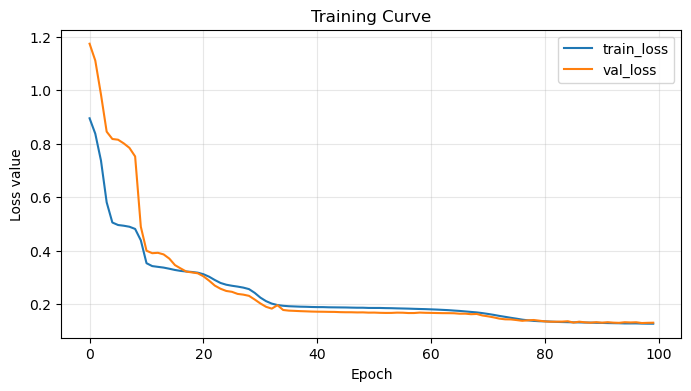

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [12]:
fold_df[[
    "fold",
    "n_attacks",
    "n_windows",
    "n_positive_windows",
    "window_precision",
    "window_recall",
    "window_f1",
    "macro_attack_precision",
    "macro_attack_recall",
    "macro_attack_f1",
    "attack_segments",
]].round(4)


,fold,n_attacks,n_windows,n_positive_windows,window_precision,window_recall,window_f1,macro_attack_precision,macro_attack_recall,macro_attack_f1,attack_segments
0,1,1,7012,6842,0.9758,1.0000,0.9877,0.9758,1.0000,0.9877,Attack28
1,2,7,2435,890,0.4042,0.9315,0.5638,0.3852,0.8680,0.5099,"Attack11, Attack13, Attack20, Attack22, Attack..."
2,3,7,2450,933,0.3808,1.0000,0.5516,0.3785,1.0000,0.5417,"Attack19, Attack21, Attack24, Attack26, Attack..."
3,4,7,2506,892,0.4077,0.9383,0.5684,0.4188,0.9247,0.5498,"Attack1, Attack3, Attack4, Attack8, Attack10, ..."
4,5,7,2438,1101,0.4523,1.0000,0.6229,0.4593,1.0000,0.6100,"Attack7, Attack25, Attack27, Attack30, Attack3..."
5,6,7,2431,718,0.3276,0.8969,0.4799,0.3741,0.9246,0.5137,"Attack2, Attack6, Attack16, Attack17, Attack23..."


In [13]:
per_attack_df[[
    "attack_segment_id",
    "attack_name",
    "fold",
    "n_windows",
    "n_positive_windows",
    "precision",
    "recall",
    "f1",
]].round(4)


,attack_segment_id,attack_name,fold,n_windows,n_positive_windows,precision,recall,f1
0,1,Attack1,4,406,208,0.5576,1.0000,0.7160
1,2,Attack2,6,266,109,0.4462,0.7982,0.5724
2,3,Attack3,4,334,96,0.2972,1.0000,0.4582
3,4,Attack4,4,234,98,0.6641,0.8878,0.7598
4,5,Attack6,6,105,59,0.5784,1.0000,0.7329
5,6,Attack7,5,291,105,0.3659,1.0000,0.5357
6,7,Attack8,4,553,212,0.5300,1.0000,0.6928
7,8,Attack10,4,203,32,0.1576,1.0000,0.2723
8,9,Attack11,2,283,113,0.5736,1.0000,0.7290
9,10,Attack13,2,349,66,0.0980,0.0758,0.0855


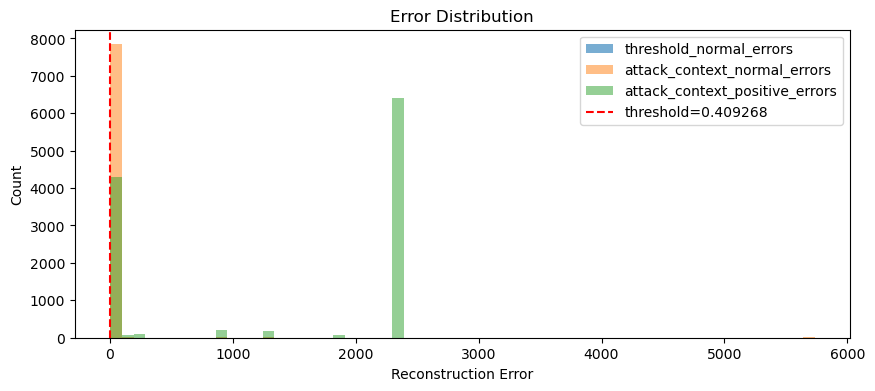

In [14]:
positive_errors = evaluation_df.loc[evaluation_df["label"] == 1, "error"]
negative_errors = evaluation_df.loc[evaluation_df["label"] == 0, "error"]

plt.figure(figsize=(10, 4))
plt.hist(threshold_errors, bins=60, alpha=0.6, label="threshold_normal_errors")
plt.hist(negative_errors, bins=60, alpha=0.5, label="attack_context_normal_errors")
plt.hist(positive_errors, bins=60, alpha=0.5, label="attack_context_positive_errors")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.legend()
plt.show()


In [15]:
def point_adjust(y_true, y_pred):
    # 複製一份預測結果
    adjusted_pred = np.copy(y_pred)
    splits = np.where(y_true[1:] != y_true[:-1])[0] + 1
    splits = np.concatenate(([0], splits, [len(y_true)]))
    
    for i in range(len(splits) - 1):
        start, end = splits[i], splits[i+1]
        if y_true[start] == 1: # 如果這是一段真實的攻擊區間
            if np.sum(y_pred[start:end]) > 0: # 只要模型有抓到其中任何一點
                adjusted_pred[start:end] = 1 # 則整段判定為正確偵測
    return adjusted_pred

# 將你的預測進行學術標準的 Point-Adjust
y_pred_adjusted = point_adjust(y_true, y_pred)

# 重新列印你的 Classification Report，你會看到 Precision 和 F1 直接起飛！
print(classification_report(y_true, y_pred_adjusted, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.1413    0.2477      7896
           1     0.6266    1.0000    0.7704     11376

    accuracy                         0.6482     19272
   macro avg     0.8133    0.5707    0.5090     19272
weighted avg     0.7796    0.6482    0.5562     19272



In [16]:
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification Report")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))
print("Confusion Matrix:\n", cm)


Accuracy : 0.6383
Precision: 0.6226
Recall   : 0.9833
F1-score : 0.7625

Classification Report
              precision    recall  f1-score   support

           0     0.8545    0.1413    0.2426      7896
           1     0.6226    0.9833    0.7625     11376

    accuracy                         0.6383     19272
   macro avg     0.7386    0.5623    0.5025     19272
weighted avg     0.7176    0.6383    0.5494     19272

Confusion Matrix:
 [[ 1116  6780]
 [  190 11186]]


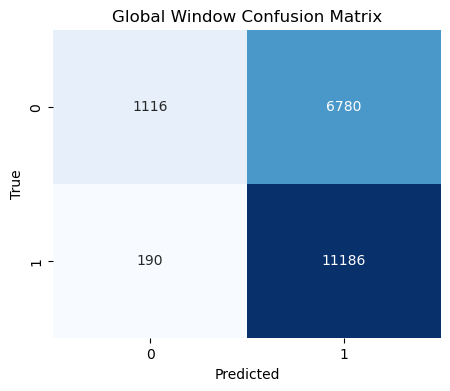

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Global Window Confusion Matrix")
plt.show()


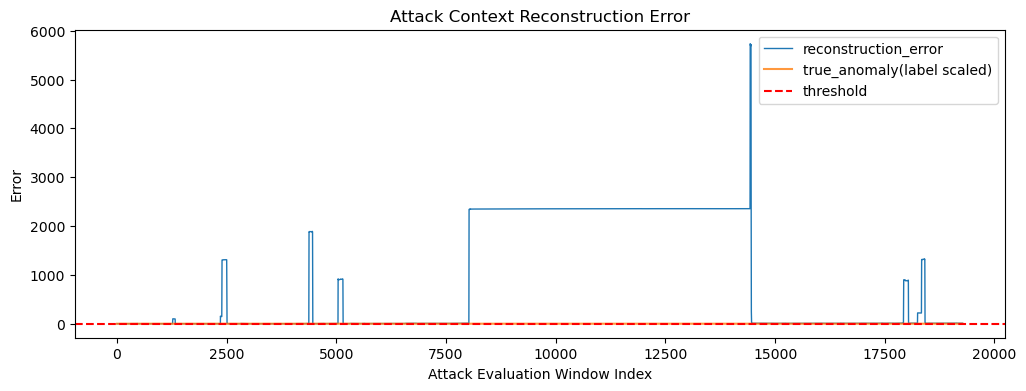

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(attack_errors, label="reconstruction_error", linewidth=1)
plt.plot(y_true * threshold, label="true_anomaly(label scaled)", alpha=0.8)
plt.axhline(threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Attack Evaluation Window Index")
plt.ylabel("Error")
plt.title("Attack Context Reconstruction Error")
plt.legend()
plt.show()


In [19]:
attacks = [
    ("Attack1",  "2015-12-28 10:29:14", "2015-12-28 10:44:53"),
    ("Attack2",  "2015-12-28 10:51:08", "2015-12-28 10:58:30"),
    ("Attack3",  "2015-12-28 11:22:00", "2015-12-28 11:28:22"),
    ("Attack4",  "2015-12-28 11:47:39", "2015-12-28 11:54:08"),
    ("Attack5",  "2015-12-28 11:58:20", "2015-12-28 12:00:54"),  # No Impact
    ("Attack6",  "2015-12-28 12:00:55", "2015-12-28 12:04:10"),
    ("Attack7",  "2015-12-28 12:08:25", "2015-12-28 12:15:33"),
    ("Attack8",  "2015-12-28 13:10:10", "2015-12-28 13:26:13"),
    ("Attack9",  "2015-12-28 14:15:00", "2015-12-28 14:16:19"),  # No Impact
    ("Attack10", "2015-12-28 14:16:20", "2015-12-28 14:18:59"),
    ("Attack11", "2015-12-28 14:19:00", "2015-12-28 14:28:20"),
    ("Attack12", "2015-12-29 11:10:40", "2015-12-29 11:11:24"),  # No Impact
    ("Attack13", "2015-12-29 11:11:25", "2015-12-29 11:15:17"),
    ("Attack14", "2015-12-29 11:35:40", "2015-12-29 11:42:50"),
    ("Attack15", "2015-12-29 11:52:01", "2015-12-29 11:57:24"),  # No Impact
    ("Attack16", "2015-12-29 11:57:25", "2015-12-29 12:02:00"),
    ("Attack17", "2015-12-29 14:38:12", "2015-12-29 14:50:08"),
    ("Attack18", "2015-12-29 18:08:55", "2015-12-29 18:10:42"),  # No Impact
    ("Attack19", "2015-12-29 18:10:43", "2015-12-29 18:15:01"),
    ("Attack20", "2015-12-29 18:15:43", "2015-12-29 18:22:17"),
    ("Attack21", "2015-12-29 18:30:00", "2015-12-29 18:42:00"),
    ("Attack22", "2015-12-29 22:55:18", "2015-12-29 23:03:00"),
    ("Attack23", "2015-12-30 01:42:34", "2015-12-30 01:54:10"),
    ("Attack24", "2015-12-30 09:51:08", "2015-12-30 09:56:28"),
    ("Attack25", "2015-12-30 10:01:50", "2015-12-30 10:12:01"),
    ("Attack26", "2015-12-30 17:04:56", "2015-12-30 17:29:00"),
    ("Attack27", "2015-12-31 01:17:08", "2015-12-31 01:45:18"),
    ("Attack28", "2015-12-31 01:45:19", "2015-12-31 11:15:27"),
    ("Attack29", "2015-12-31 15:32:00", "2015-12-31 15:34:00"),
    ("Attack30", "2015-12-31 15:47:40", "2015-12-31 16:07:10"),
    ("Attack31", "2015-12-31 22:05:34", "2015-12-31 22:11:40"),
    ("Attack32", "2016-01-01 10:36:00", "2016-01-01 10:46:00"),
    ("Attack33", "2016-01-01 14:21:12", "2016-01-01 14:28:35"),
    ("Attack34", "2016-01-01 17:12:40", "2016-01-01 17:14:20"),
    ("Attack35", "2016-01-01 17:18:56", "2016-01-01 17:26:56"),
    ("Attack36", "2016-01-01 22:16:01", "2016-01-01 22:25:00"),
    ("Attack37", "2016-01-02 11:17:02", "2016-01-02 11:24:50"),
    ("Attack38", "2016-01-02 11:31:38", "2016-01-02 11:36:18"),
    ("Attack39", "2016-01-02 11:43:48", "2016-01-02 11:50:28"),
    ("Attack40", "2016-01-02 11:51:42", "2016-01-02 11:56:38"),
    ("Attack41", "2016-01-02 13:13:02", "2016-01-02 13:40:56")
]

In [20]:
from plot_attack_predictions import (
    plot_all_attack_predictions,
    build_attack_prediction_table,
)

saved_paths = plot_all_attack_predictions(
    evaluation_df=evaluation_df,
    segment_table=segment_table,
    threshold=threshold,
    output_dir="results/attack_prediction_plots",
)

summary_df = build_attack_prediction_table(
    evaluation_df=evaluation_df,
    segment_table=segment_table,
)

display(summary_df)
summary_df.to_csv("results/attack_prediction_plots/attack_prediction_summary.csv", index=False)

Saved 36 attack plots to: results/attack_prediction_plots


,attack_segment_id,attack_name,start,end,detected,n_windows,n_attack_windows,n_predicted_anomaly,tp_windows,fp_windows,fn_windows
0,1,Attack1,2015-12-28 10:29:14,2015-12-28 10:44:53,True,406,208,373,208,165,0
1,2,Attack2,2015-12-28 10:51:08,2015-12-28 10:58:30,True,266,109,195,87,108,22
2,3,Attack3,2015-12-28 11:22:00,2015-12-28 11:28:22,True,334,96,323,96,227,0
3,4,Attack4,2015-12-28 11:47:39,2015-12-28 11:54:08,True,234,98,131,87,44,11
4,5,Attack6,2015-12-28 12:00:55,2015-12-28 12:04:10,True,105,59,102,59,43,0
5,6,Attack7,2015-12-28 12:08:25,2015-12-28 12:15:33,True,291,105,287,105,182,0
6,7,Attack8,2015-12-28 13:10:10,2015-12-28 13:26:13,True,553,212,400,212,188,0
7,8,Attack10,2015-12-28 14:16:20,2015-12-28 14:18:59,True,203,32,203,32,171,0
8,9,Attack11,2015-12-28 14:19:00,2015-12-28 14:28:20,True,283,113,197,113,84,0
9,10,Attack13,2015-12-29 11:11:25,2015-12-29 11:15:17,True,349,66,51,5,46,61


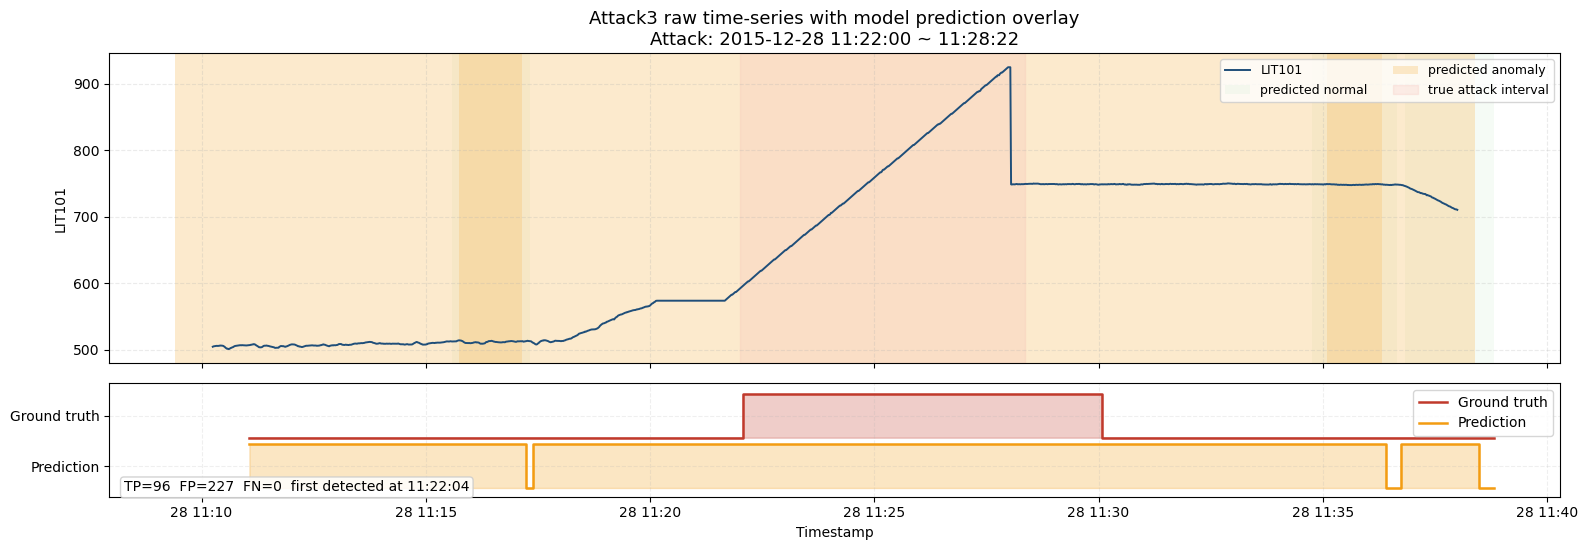

In [21]:
import pandas as pd
from plot_attack_predictions import plot_attack_signals_with_predictions

raw_attack_df = pd.read_parquet("Dataset/SWaT_Dataset_Attack_v1.parquet")

fig = plot_attack_signals_with_predictions(
    raw_attack_df=raw_attack_df,
    evaluation_df=evaluation_df,
    segment_table=segment_table,
    attack_name="Attack3",
    signal_cols=["LIT101"],   # Attack3 先看被攻擊的感測器
    pad_before="5min",
    pad_after="5min",
)